# Target Corporation: Quarterly Revenue Analysis

**Prepared for:** Chapman Wealth Management
**Prepared by:** QuantFolio Solutions

Chapman Wealth Management is evaluating an investment in Target Corporation (ticker: **TGT**) and wants
to understand the structure of Target's quarterly revenue. This notebook loads Target's historical
quarterly revenue, identifies the two dominant patterns in the data (a steady upward trend and a
recurring holiday spike), and fits a regression model that separates and quantifies those effects.

**Approach:** time-series regression using *time* plus **exactly two dummy variables** as the
independent variables, with quarterly revenue (saleq) as the dependent variable. bold text bold text

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Show dollar figures with two decimals rather than scientific notation
pd.options.display.float_format = '{:.2f}'.format

## 1. Data Exploration

Load the full quarterly-sales dataset, isolate Target, and plot the series to see what patterns
the model needs to capture.

In [ ]:
# Load the full quarterly sales dataset (contains several companies)
qSales = pd.read_csv('qSales_2024.csv')
display(qSales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,102450,2022-12-31,2022,3,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2022Q4,2022Q3,5280.78,A
273,102450,2023-03-31,2022,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q1,2022Q4,2226.88,A
274,102450,2023-06-30,2023,1,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q2,2023Q1,3190.81,A
275,102450,2023-09-30,2023,2,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q3,2023Q2,2140.04,A


In [ ]:
# Keep only Target's rows. .copy() gives us an independent DataFrame so the
# columns we add below don't raise a SettingWithCopyWarning.
target_sales = qSales.loc[qSales['tic'] == 'TGT'].copy()
display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


In [ ]:
# Make sure the date column is a real datetime -- important for time-series work
target_sales['datadate'] = pd.to_datetime(target_sales['datadate'])

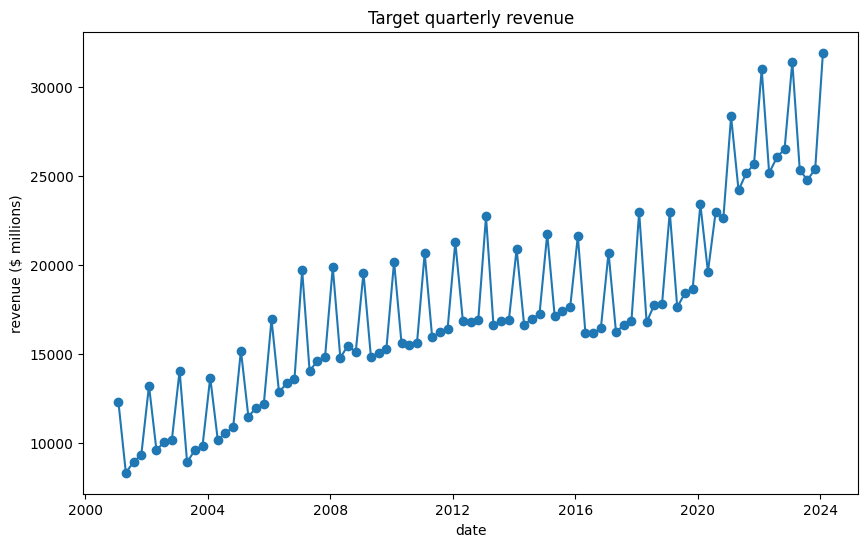

In [ ]:
# Always visualize first: plot quarterly revenue over time
plt.figure(figsize=(10, 6))
plt.title('Target quarterly revenue')
plt.xlabel('date')
plt.ylabel('revenue ($ millions)')
plt.plot(target_sales['datadate'], target_sales['saleq'], marker='o')
plt.show()

**What the plot shows.** Two patterns dominate:

1. **A steady upward trend** revenue drifts higher across the full history.
2. **A sharp annual spike** every fiscal Q4 (the November–January holiday quarter, which contains
   the November–December shopping season) jumps well above the surrounding quarters.

The model below is built to capture *both* of these effects separately.

## 2. Model Development

### Independent variables

- time  a simple period counter (1, 2, 3, …) that captures the underlying growth trend.
- Dummy 1  holiday_dummy  equals 1 in the holiday quarter (fiscal Q4) and 0 otherwise.
  It measures how much extra revenue the holiday quarter earns.
- Dummy 2  holiday_interaction  time × holiday_dummy. It lets the size of the holiday
  bump change over time, testing whether the holiday premium is growing or shrinking as Target grows.

Final specification: saleq = β0 + β1·time + β2·holiday_dummy + β3·holiday_interaction

In [ ]:
# Add the time index: 1, 2, 3, ... one per quarter in order
target_sales['time'] = range(1, len(target_sales) + 1)

In [ ]:
# DUMMY 1: holiday-quarter seasonal dummy.
# For Target, fiscal Q4 (fqtr == 4) is the Nov-Jan holiday quarter.
target_sales['holiday_dummy'] = np.where(target_sales['fqtr'] == 4, 1, 0)

# DUMMY 2: interaction between time and the holiday dummy.
# Lets the holiday premium grow or shrink over the years.
target_sales['holiday_interaction'] = target_sales['time'] * target_sales['holiday_dummy']

display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,holiday_dummy,holiday_interaction
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2,0,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3,0,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4,0,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89,1,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90,0,0
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91,0,0
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92,0,0


### Train / test split

We fit the model on the first 75% of quarters and hold out the final 25% to check how the model
performs on data it has not seen.

In [ ]:
# First 75% of rows for training, remaining 25% for testing
dt4training = target_sales[:int(0.75 * len(target_sales))]
dt4testing  = target_sales[int(0.75 * len(target_sales)):]

display(dt4training)
display(dt4testing)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,holiday_dummy,holiday_interaction
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2,0,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3,0,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4,0,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,3813,2017-01-31,2016,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2016Q4,2016Q4,20690.00,A,65,1,65
157,3813,2017-04-30,2017,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2017Q1,2017Q1,16223.00,A,66,0,0
158,3813,2017-07-31,2017,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2017Q2,2017Q2,16634.00,A,67,0,0
159,3813,2017-10-31,2017,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2017Q3,2017Q3,16874.00,A,68,0,0


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,holiday_dummy,holiday_interaction
161,3813,2018-04-30,2018,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q1,2018Q1,16781.00,A,70,0,0
162,3813,2018-07-31,2018,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q2,2018Q2,17777.00,A,71,0,0
163,3813,2018-10-31,2018,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q3,2018Q3,17821.00,A,72,0,0
164,3813,2019-01-31,2018,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2018Q4,2018Q4,22977.00,A,73,1,73
165,3813,2019-04-30,2019,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q1,2019Q1,17627.00,A,74,0,0
166,3813,2019-07-31,2019,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q2,2019Q2,18422.00,A,75,0,0
167,3813,2019-10-31,2019,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q3,2019Q3,18664.00,A,76,0,0
168,3813,2020-01-31,2019,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2019Q4,2019Q4,23399.00,A,77,1,77
169,3813,2020-04-30,2020,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2020Q1,2020Q1,19615.00,A,78,0,0
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2020Q2,2020Q2,22975.00,A,79,0,0


In [ ]:
# Prepare the independent variables (time + the two dummies) and add an intercept
x = dt4training.loc[:, ['time', 'holiday_dummy', 'holiday_interaction']]
x = sm.add_constant(x)

# Dependent variable: quarterly revenue
y = dt4training.loc[:, 'saleq']

# Fit the OLS regression
model1 = sm.OLS(y, x).fit()
model1.params

,0
const,9470.64
time,134.90
holiday_dummy,4006.81
holiday_interaction,15.53


### Interpreting the coefficients

Revenue is reported in **millions of dollars**, so the coefficients read as follows
(your exact numbers will match the output above):

- Intercept (~9,471)  baseline revenue at the start of the series in a non-holiday quarter.
- time (~135) — ordinary trend growth of roughly $135 million per quarter.
- holiday_dummy (~4,007)  a holiday quarter earns about $4.0 billion more than a normal quarter.
- holiday_interaction (~16)the holiday premium widens only slightly each quarter, so almost all
  of Target's growth comes from the steady trend rather than from ever-bigger holidays.

Full regression summary:

In [ ]:
# Full statistical detail (R-squared, p-values, confidence intervals, etc.)
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  saleq   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     187.0
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           6.65e-32
Time:                        01:02:47   Log-Likelihood:                -585.07
No. Observations:                  69   AIC:                             1178.
Df Residuals:                      65   BIC:                             1187.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                9470.6430    343.757     27.550      0.000    8784.113    1.02e+04
time                  134.8993      8.568     15.744      0.000     117.788     152.011
holiday_dummy        4006.8090    652.507      6.141      0.000    2703.663    5309.955
holiday_interaction    15.5259     16.100      0.964      0.338     -16.627      47.679
==============================================================================
Omnibus:                        5.706   Durbin-Watson:                   0.194
Prob(Omnibus):                  0.058   Jarque-Bera (JB):                2.616
Skew:                          -0.169   Prob(JB):                        0.270
Kurtosis:                       2.108   Cond. No.                         198.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Forecasts on the held-out test set

In [ ]:
# Predict the 25% we held out, with 80% prediction intervals (alpha = 0.2)
x_test = dt4testing.loc[:, ['time', 'holiday_dummy', 'holiday_interaction']]
x_test = sm.add_constant(x_test)

model1.get_prediction(x_test).summary_frame(alpha=0.2)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
161,18913.59,343.76,18468.53,19358.66,17297.35,20529.84
162,19048.49,351.26,18593.72,19503.27,17429.54,20667.44
163,19183.39,358.80,18718.84,19647.94,17561.67,20805.11
164,24458.49,590.15,23694.41,25222.57,22727.02,26189.96
165,19453.19,374.03,18968.93,19937.45,17825.71,21080.67
166,19588.09,381.70,19093.89,20082.29,17957.63,21218.55
167,19722.99,389.42,19218.81,20227.17,18089.47,21356.50
168,25060.19,638.54,24233.47,25886.92,23300.18,26820.20
169,19992.79,404.94,19468.50,20517.07,18352.96,21632.62
170,20127.69,412.75,19593.29,20662.08,18484.59,21770.78


## 3. Analysis Output

### Actual revenue vs. model predictions

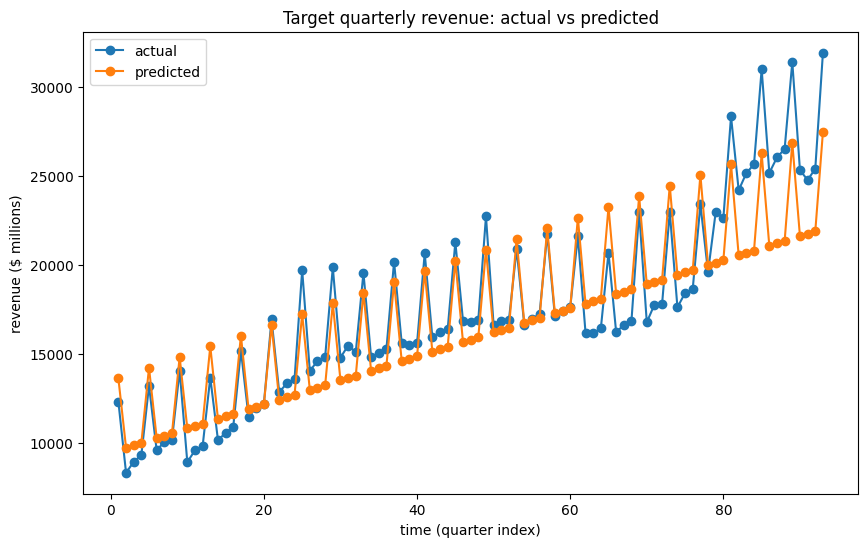

In [ ]:
# Predict across the FULL dataset so we can compare fitted vs actual everywhere
x_all = target_sales.loc[:, ['time', 'holiday_dummy', 'holiday_interaction']]
x_all = sm.add_constant(x_all)
target_sales['predicted'] = model1.predict(x_all)

plt.figure(figsize=(10, 6))
plt.title('Target quarterly revenue: actual vs predicted')
plt.xlabel('time (quarter index)')
plt.ylabel('revenue ($ millions)')
plt.plot(target_sales['time'], target_sales['saleq'],    marker='o', label='actual')
plt.plot(target_sales['time'], target_sales['predicted'], marker='o', label='predicted')
plt.legend()
plt.show()

Memo: Target Corporation Revenue Analysis

To: Chapman Wealth Management
From: QuantFolio Solutions
Re: Target quarterly revenue patterns

Bottom line: Target's revenue is highly seasonal but very predictable, and it is growing off a steady trend rather than a widening holiday effect. The model's recent forecasts should be read as a conservative floor.

Scope: We analyzed Target's quarterly revenue from 2000 through early 2023 to help Chapman understand the structure of the business ahead of a potential investment.

Methodology: We ran a linear regression of quarterly revenue on a time trend plus two dummies, one flagging the holiday quarter (fiscal Q4) and one testing whether that holiday effect changes over time. We fit on the first 75 percent of quarters and held out the rest to check the forecasts.

Key findings: The model explains about 89 percent of the variation in revenue. Revenue grows by roughly 135 million dollars per quarter on trend, and the holiday quarter adds about 4 billion dollars over a normal quarter. There is no reliable evidence the holiday premium is widening (that term is not statistically significant), so growth comes from the underlying trend, not bigger holidays. The model under-predicts the most recent two years, where real holiday spikes have run ahead of the trend line.

Recommendations: Treat every result seasonally. The holiday quarter distorts any raw quarter to quarter comparison, so adjust for it before drawing conclusions. Read the model's recent forecasts as a floor rather than a base case, since Target has lately out-earned its own trend. The steady, broad based growth supports a constructive view, but confirm the recent acceleration is structural rather than a temporary pull-forward before sizing a position.